# SmartSwipe — Assignment 1

**Dataset:** `transactions.csv`  
Explore the dataset on your own, find out about the different columns in the dataset. 

---


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

---
## Q1 — Python Fundamentals `[10 pts]`

You are given the list `amounts` below.

1. Write a function `summarise(amounts, threshold)` that returns a **dict** with keys:
   - `above_threshold`: list of values strictly greater than `threshold`, sorted descending
   - `mean`: arithmetic mean (no libraries)
   - `count_above`: integer count
2. Call it with `threshold=500` and print the result.


In [2]:
file_path = "transactions.csv"
amounts = pd.read_csv(file_path, usecols=["amount"])["amount"].dropna().tolist()


def summarise(amounts, threshold):
    above = sorted([x for x in amounts if x > threshold], reverse=True)
    count_above = len(above)
    mean = sum(amounts) / len(amounts) if amounts else 0
    return {
        "above_threshold": above,
        "mean": mean,
        "count_above": count_above,
    }


result = summarise(amounts, threshold=500)
print(result)


{'above_threshold': [14205.88, 14011.64, 13184.18, 13086.34, 12304.94, 12250.73, 12199.01, 11818.92, 11772.79, 11662.54, 11471.08, 11371.61, 11234.88, 11199.06, 11195.5, 11101.87, 11073.38, 11069.15, 11007.74, 10905.49, 10864.93, 10713.45, 10491.16, 10380.89, 10359.9, 10312.18, 10252.55, 10151.58, 10150.55, 10095.57, 9796.81, 9794.37, 9783.26, 9764.67, 9716.4, 9612.35, 9608.31, 9600.26, 9593.46, 9568.04, 9492.12, 9468.63, 9421.41, 9420.5, 9416.27, 9376.75, 9323.98, 9311.32, 9244.25, 9211.58, 9126.68, 9093.21, 9051.72, 9026.74, 9016.71, 8991.0, 8891.44, 8880.77, 8858.52, 8828.05, 8807.32, 8786.62, 8769.03, 8713.76, 8698.26, 8687.37, 8678.88, 8671.19, 8657.93, 8651.19, 8649.46, 8643.98, 8628.76, 8604.56, 8600.0, 8591.48, 8535.93, 8504.49, 8465.53, 8427.74, 8426.91, 8375.23, 8358.33, 8317.36, 8290.01, 8255.59, 8217.94, 8211.15, 8191.41, 8187.97, 8173.21, 8154.55, 8151.36, 8089.08, 8081.51, 8077.92, 8054.42, 8021.97, 8015.36, 8010.49, 7982.2, 7973.71, 7950.58, 7946.57, 7941.33, 7901.92, 78

---
## Q2 — NumPy `[15 pts]`

Load **only** the `amount` column into a NumPy array. Then:

1. Print mean, median, std, 10th and 90th percentiles.
2. Create a boolean mask for **outlier** transactions: those where `|amount − mean| > 2 × std`.
3. Normalise the array to `[0, 1]` using min-max scaling and store it as `amounts_norm`.
4. Using `np.histogram`, compute a 10-bin histogram of `amounts_norm` and print bin edges + counts (no plot needed).


In [3]:
file_path = "transactions.csv"
amounts_np = pd.read_csv(file_path, usecols=["amount"]).to_numpy(dtype=float).ravel()

mean_val = amounts_np.mean()
median_val = np.median(amounts_np)
std_val = amounts_np.std()
p10, p90 = np.percentile(amounts_np, [10, 90])

print("mean:", mean_val)
print("median:", median_val)
print("std:", std_val)
print("p10:", p10)
print("p90:", p90)

outlier_mask = np.abs(amounts_np - mean_val) > 2 * std_val

min_val = amounts_np.min()
max_val = amounts_np.max()
if max_val == min_val:
    amounts_norm = np.zeros_like(amounts_np)
else:
    amounts_norm = (amounts_np - min_val) / (max_val - min_val)

counts, edges = np.histogram(amounts_norm, bins=10, range=(0, 1))
print("hist_counts:", counts)
print("hist_edges:", edges)


mean: 1253.0228844667695
median: 433.385
std: 1989.756920338982
p10: 88.25
p90: 4024.015
hist_counts: [4020  479  191  187  141   81   47   18    8    4]
hist_edges: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


---
## Q3 — Pandas: Load & Explore `[15 pts]`

1. Load `smartswipe_transactions.csv` into a DataFrame `df`.
2. Print shape, dtypes, and count of missing values per column.
3. Parse `date` as `datetime` (in-place). Add a column `month` (integer, 1–12).
4. Print the statistical summary for numeric columns only.
5. How many unique `city` and `category` values exist? Print them.


In [4]:
file_path = "transactions.csv"
df = pd.read_csv(file_path)

print("shape:", df.shape)
print(df.dtypes)
print(df.isna().sum())

if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
elif "datetime" in df.columns:
    df["date"] = pd.to_datetime(df["datetime"], errors="coerce")

if "date" in df.columns:
    df["month"] = df["date"].dt.month

numeric_summary = df.select_dtypes(include=[np.number]).describe()
print(numeric_summary)

if "city" in df.columns:
    cities = df["city"].dropna().unique()
    print("unique cities:", len(cities))
    print("cities:", cities)
else:
    print("unique cities: 0")

if "category" in df.columns:
    categories = df["category"].dropna().unique()
    print("unique categories:", len(categories))
    print("categories:", categories)
else:
    print("unique categories: 0")


shape: (5176, 9)
txn_id       object
user_id      object
merchant     object
category     object
amount      float64
datetime     object
city         object
cashback    float64
status       object
dtype: object
txn_id        0
user_id       0
merchant      0
category      0
amount        0
datetime      0
city          0
cashback    258
status        0
dtype: int64
             amount     cashback        month
count   5176.000000  4918.000000  5176.000000
mean    1253.022884    29.513211     3.455564
std     1989.949158    87.547840     1.678726
min       10.000000     0.000000     1.000000
25%      173.882500     1.070000     2.000000
50%      433.385000     6.565000     3.000000
75%     1251.317500    21.355000     5.000000
max    14205.880000  2440.530000     6.000000
unique cities: 9
cities: ['Delhi' 'Hyderabad' 'Chennai' 'Mumbai' 'Jaipur' 'Pune' 'Kanpur'
 'Bangalore' 'Kolkata']
unique categories: 9
categories: ['Shopping' 'Healthcare' 'Utilities' 'Groceries' 'Travel' 'Fuel' 'Dinin

---
## Q4 — Pandas: Filter & Transform `[20 pts]`

1. Filter to **approved** transactions only. What fraction of total transactions is this? Print as a percentage.
2. Add column `cashback_rate` = `cashback / amount`. Flag rows where this exceeds 0.10 as `suspicious` (boolean column).
3. Fill any missing `cashback` values with the **per-category median** cashback (do not use a global fill).
4. Create a `spend_tier` column: `low` (amount < 500), `mid` (500–2000), `high` (> 2000).
   Use `pd.cut` — do not write if-else chains.


In [5]:
status_col = next(
    (c for c in ["status", "transaction_status", "approval_status", "approved", "decision", "is_approved"] if c in df.columns),
    None,
)
if status_col is None:
    raise KeyError("No status column found to identify approved transactions.")

status_series = df[status_col]
if status_series.dtype == bool:
    approved_mask = status_series
else:
    approved_mask = status_series.astype(str).str.lower().isin(["approved", "true", "1", "yes"])

approved_pct = approved_mask.mean() * 100
print(f"approved fraction: {approved_pct:.2f}%")

if "cashback" not in df.columns:
    raise KeyError("No cashback column found.")
if "amount" not in df.columns:
    raise KeyError("No amount column found.")

if "category" in df.columns:
    df["cashback"] = df["cashback"].fillna(df.groupby("category")["cashback"].transform("median"))
else:
    df["cashback"] = df["cashback"].fillna(df["cashback"].median())

df["cashback_rate"] = df["cashback"] / df["amount"].replace(0, np.nan)
df["suspicious"] = df["cashback_rate"] > 0.10

df["spend_tier"] = pd.cut(
    df["amount"],
    bins=[-np.inf, 500, 2000, np.inf],
    labels=["low", "mid", "high"],
    right=False,
)


approved fraction: 88.97%


---
## Q5 — Pandas: Aggregation `[20 pts]`

1. For each `category`, compute: total spend, transaction count, avg transaction size, decline rate.
   Store as a clean DataFrame `category_stats` and print it sorted by total spend descending.
2. Find the **top-3 merchants** by total spend within each city. Output should be a DataFrame with columns `city`, `merchant`, `total_spend`.
3. Build a **month × category pivot table** of average transaction amounts. Print it.


In [6]:
status_col = next(
    (c for c in ["status", "transaction_status", "approval_status", "approved", "decision", "is_approved"] if c in df.columns),
    None,
)
if status_col is None:
    raise KeyError("No status column found to compute decline rate.")

status_series = df[status_col]
if status_series.dtype == bool:
    approved_mask = status_series
else:
    approved_mask = status_series.astype(str).str.lower().isin(["approved", "true", "1", "yes"])

declined_mask = ~approved_mask

category_stats = df.groupby("category").agg(
    total_spend=("amount", "sum"),
    transaction_count=("amount", "size"),
    avg_transaction_size=("amount", "mean"),
)
category_stats["decline_rate"] = df.groupby("category").apply(lambda x: declined_mask.loc[x.index].mean())
category_stats = category_stats.sort_values("total_spend", ascending=False)
print(category_stats)

if "city" in df.columns and "merchant" in df.columns:
    city_merchant = df.groupby(["city", "merchant"], as_index=False)["amount"].sum()
    city_merchant = city_merchant.rename(columns={"amount": "total_spend"})
    top3_merchants = (
        city_merchant.sort_values(["city", "total_spend"], ascending=[True, False])
        .groupby("city", as_index=False)
        .head(3)
        .reset_index(drop=True)
    )
    print(top3_merchants)
else:
    print("city/merchant columns not found for top-3 merchants output.")

if "month" not in df.columns and "date" in df.columns:
    df["month"] = pd.to_datetime(df["date"], errors="coerce").dt.month

if "month" in df.columns and "category" in df.columns:
    pivot = df.pivot_table(index="month", columns="category", values="amount", aggfunc="mean")
    print(pivot)
else:
    print("month/category columns not found for pivot table.")


               total_spend  transaction_count  avg_transaction_size  \
category                                                              
Travel          2213273.63                444           4984.850518   
Electronics     1722710.26                384           4486.224635   
Shopping        1031848.97                651           1585.021459   
Healthcare       438697.56                420           1044.518000   
Dining           371893.93                768            484.236888   
Utilities        290547.44                390            744.993436   
Groceries        195293.44                905            215.793856   
Entertainment    153913.21                527            292.055427   
Fuel              67468.01                687             98.206710   

               decline_rate  
category                     
Travel             0.340090  
Electronics        0.377604  
Shopping           0.188940  
Healthcare         0.061905  
Dining             0.045573  
Utilitie

C:\Users\aksha\AppData\Local\Temp\ipykernel_9992\1782324620.py:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  category_stats["decline_rate"] = df.groupby("category").apply(lambda x: declined_mask.loc[x.index].mean())


---
## Q6 — Matplotlib: Visualisation `[20 pts]`

Produce a single `fig` with **3 subplots** (layout your choice):

1. **Bar chart** — Total spend per category. Sort bars descending. Label axes.
2. **Line chart** — Daily total spend over time. Use `date` on x-axis. Rotate tick labels 45°.
3. **Histogram** — Distribution of `amount` for approved vs declined transactions overlaid (use `alpha=0.6`). Add a legend.

Titles, axis labels, and `fig.tight_layout()` are required.


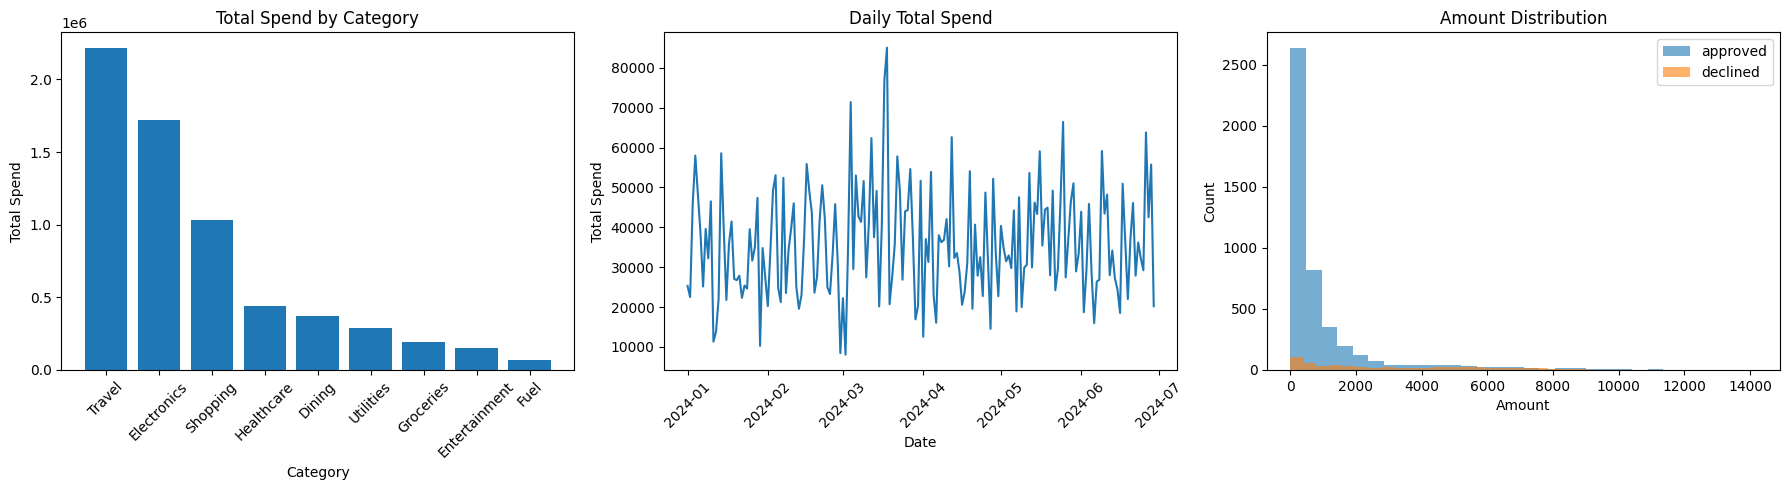

In [7]:
if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
elif "datetime" in df.columns:
    df["date"] = pd.to_datetime(df["datetime"], errors="coerce")

status_col = next(
    (c for c in ["status", "transaction_status", "approval_status", "approved", "decision", "is_approved"] if c in df.columns),
    None,
)
if status_col is None:
    raise KeyError("No status column found to separate approved vs declined.")

status_series = df[status_col]
if status_series.dtype == bool:
    approved_mask = status_series
else:
    approved_mask = status_series.astype(str).str.lower().isin(["approved", "true", "1", "yes"])

declined_mask = ~approved_mask

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

category_totals = df.groupby("category")["amount"].sum().sort_values(ascending=False)
axs[0].bar(category_totals.index.astype(str), category_totals.values)
axs[0].set_title("Total Spend by Category")
axs[0].set_xlabel("Category")
axs[0].set_ylabel("Total Spend")
axs[0].tick_params(axis="x", rotation=45)

daily_spend = df.dropna(subset=["date"]).set_index("date").resample("D")["amount"].sum()
axs[1].plot(daily_spend.index, daily_spend.values)
axs[1].set_title("Daily Total Spend")
axs[1].set_xlabel("Date")
axs[1].set_ylabel("Total Spend")
axs[1].tick_params(axis="x", rotation=45)

axs[2].hist(df.loc[approved_mask, "amount"], bins=30, alpha=0.6, label="approved")
axs[2].hist(df.loc[declined_mask, "amount"], bins=30, alpha=0.6, label="declined")
axs[2].set_title("Amount Distribution")
axs[2].set_xlabel("Amount")
axs[2].set_ylabel("Count")
axs[2].legend()

fig.tight_layout()


---
## Q7 — Bonus `[30 pts]`

> This question is intentionally hard. Not compulsory.

**SmartSwipe Velocity Fraud Detector**

A transaction is part of a **velocity fraud event** if a single `user_id` has **≥ 3 transactions within any rolling 1-hour window**.

Date and Time are available in the CSV.

Tasks:

1. Write a function `flag_velocity_fraud(df, window='1h', min_txns=3)` that returns a boolean Series aligned to `df.index` — `True` if the transaction falls inside a fraud window for that user.
   - Must handle per-user sorted datetime correctly.
   - No row-wise Python loops over the full DataFrame.
2. Add column `velocity_fraud` using your function.
3. Compare flagged vs normal users on: avg spend, decline rate, top categories. Print a clean summary table.
4. Plot a **timeline scatter** (x = datetime, y = user_id, colour = velocity_fraud). Limit to 20 users for readability.


                  avg_spend  decline_rate
velocity_fraud                           
False           1152.299013      0.079047
True            4064.850726      0.983240
   velocity_fraud                   top_categories
0           False        [Groceries, Dining, Fuel]
1            True  [Travel, Electronics, Shopping]


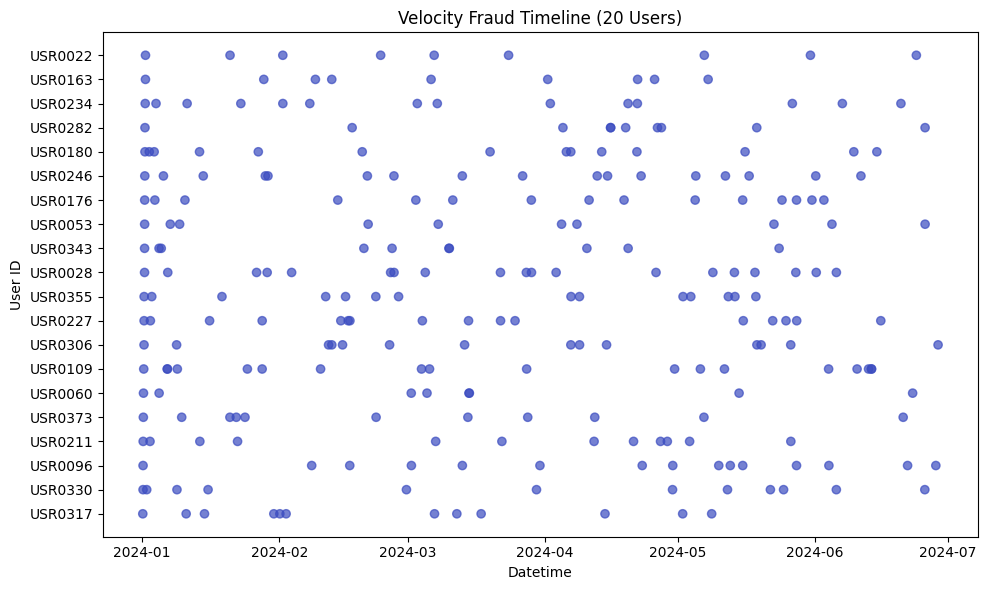

In [8]:
def _get_datetime_series(data):
    if "datetime" in data.columns:
        return pd.to_datetime(data["datetime"], errors="coerce")
    if "date" in data.columns and "time" in data.columns:
        return pd.to_datetime(
            data["date"].astype(str) + " " + data["time"].astype(str),
            errors="coerce",
        )
    if "date" in data.columns:
        return pd.to_datetime(data["date"], errors="coerce")
    raise KeyError("No datetime/date columns found.")


def _get_user_col(data):
    return next((c for c in ["user_id", "userid", "user"] if c in data.columns), None)


def flag_velocity_fraud(data, window="1h", min_txns=3):
    user_col = _get_user_col(data)
    if user_col is None:
        raise KeyError("No user_id column found.")

    dt = _get_datetime_series(data)
    result = pd.Series(False, index=data.index)
    window_delta = pd.Timedelta(window).to_timedelta64()

    for _, idx in data.groupby(user_col).groups.items():
        times = dt.loc[idx].sort_values()
        if times.isna().all():
            continue
        order = times.index
        tvals = times.values.astype("datetime64[ns]")
        end_times = tvals + window_delta
        j = np.searchsorted(tvals, end_times, side="right") - 1
        i = np.arange(len(tvals))
        valid = (j - i + 1) >= min_txns
        # Mark all indices covered by any valid window start.
        max_reach = np.maximum.accumulate(np.where(valid, j, -1))
        result.loc[order] = max_reach >= i

    return result


user_col = _get_user_col(df)
if user_col is None:
    raise KeyError("No user_id column found in df.")

df["velocity_fraud"] = flag_velocity_fraud(df, window="1h", min_txns=3)

status_col = next(
    (c for c in ["status", "transaction_status", "approval_status", "approved", "decision", "is_approved"] if c in df.columns),
    None,
)
if status_col is None:
    raise KeyError("No status column found to compute decline rate.")

status_series = df[status_col]
if status_series.dtype == bool:
    approved_mask = status_series
else:
    approved_mask = status_series.astype(str).str.lower().isin(["approved", "true", "1", "yes"])

df["declined"] = ~approved_mask

summary = df.groupby("velocity_fraud").agg(
    avg_spend=("amount", "mean"),
    decline_rate=("declined", "mean"),
)
print(summary)

top_categories = (
    df.groupby("velocity_fraud")["category"]
    .apply(lambda s: s.value_counts().head(3).index.tolist())
    .rename("top_categories")
    .reset_index()
)
print(top_categories)

df_plot = df.copy()
df_plot["_dt"] = _get_datetime_series(df_plot)
users_20 = df_plot[user_col].dropna().unique()[:20]
plot_subset = df_plot[df_plot[user_col].isin(users_20)].dropna(subset=["_dt"])

plt.figure(figsize=(10, 6))
plt.scatter(
    plot_subset["_dt"],
    plot_subset[user_col],
    c=plot_subset["velocity_fraud"].map({False: 0, True: 1}),
    cmap="coolwarm",
    alpha=0.7,
)
plt.title("Velocity Fraud Timeline (20 Users)")
plt.xlabel("Datetime")
plt.ylabel("User ID")
plt.tight_layout()
